In [1986]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [1987]:
df = pd.read_csv("titanic.csv")
df = df.copy()
df.shape

(418, 12)

In [1988]:
df.info()
df.dtypes
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [1989]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [1990]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

Data Cleaning

Missing Values:
    For numerical data like Age, Fare using median is better that the mean because it is not effected by outliners
    For categorical Data like Embraked using Mode is ideal which is most frequent value in the column
    For a in too many missing values like cabin imputing is not effective. we could either drop the column from our analysis or engineer a new feature from it. like making a column that have that a passenger have the cabin or not Has_cabin

In [1991]:
# to handel the missing values in Age we use median to fill Nulls
missing_values = df["Age"].median()

df["Age"] = df["Age"].fillna(missing_values)

In [1992]:
mode = df['Embarked'].mode()[0]

df['Embarked'] = df['Embarked'].fillna(mode)
df

C:\Users\aldwin\AppData\Roaming\Python\Python314\site-packages\IPython\core\displayhook.py:292: UserWarning: Output cache limit (currently 1000 entries) hit.
Flushing oldest 200 entries.
  warn('Output cache limit (currently {sz} entries) hit.\n'


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,27.0,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,0,3,"Ware, Mr. Frederick",male,27.0,0,0,359309,8.0500,NaN,S


In [1993]:
#Creating a new column HasCabin which has value 1 for cabin and 0 for null cabin
df['HasCabin']= df['Cabin'].notna().astype(int) # 1 if has cabin, 0 if not
df.drop('Cabin', axis=1, inplace= True) #Drop the original cabin column
df['HasCabin'].value_counts()

HasCabin
0    327
1     91
Name: count, dtype: int64

In [1994]:
#Checking for any missing values after cleaning

df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           1
Embarked       0
HasCabin       0
dtype: int64

In [1995]:
df = df[df["Survived"] == 1].reset_index()
df

,index,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,HasCabin
0,1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,S,0
1,4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,S,0
2,6,898,1,3,"Connolly, Miss. Kate",female,30.0,0,0,330972,7.6292,Q,0
3,8,900,1,3,"Abrahim, Mrs. Joseph (Sophie Halaut Easu)",female,18.0,0,0,2657,7.2292,C,0
4,12,904,1,1,"Snyder, Mrs. John Pillsbury (Nelle Stevenson)",female,23.0,1,0,21228,82.2667,S,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
147,409,1301,1,3,"Peacock, Miss. Treasteall",female,3.0,1,1,SOTON/O.Q. 3101315,13.7750,S,0
148,410,1302,1,3,"Naughton, Miss. Hannah",female,27.0,0,0,365237,7.7500,Q,0
149,411,1303,1,1,"Minahan, Mrs. William Edward (Lillian E Thorpe)",female,37.0,1,0,19928,90.0000,Q,1
150,412,1304,1,3,"Henriksson, Miss. Jenny Lovisa",female,28.0,0,0,347086,7.7750,S,0


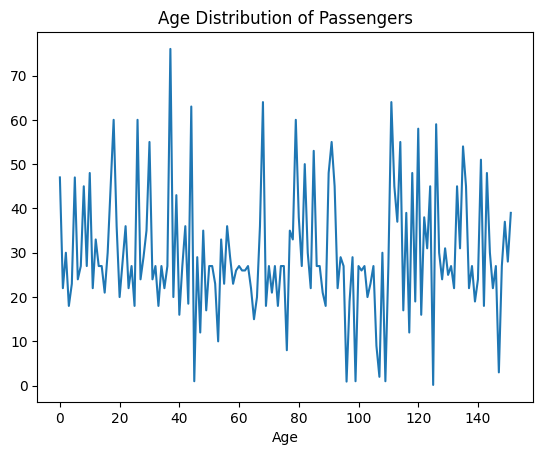

In [1996]:
df['Age'].plot(kind='line')
plt.xlabel('Age')
plt.title('Age Distribution of Passengers')
plt.show()

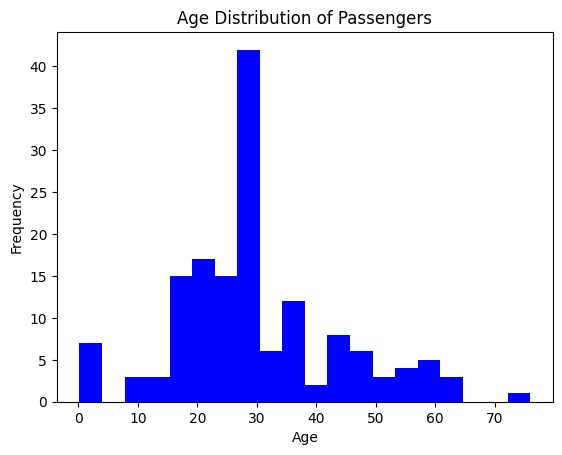

In [1997]:
df['Age'].plot(kind='hist', bins=20, color='blue')
plt.xlabel('Age')
plt.title('Age Distribution of Passengers')
plt.show()

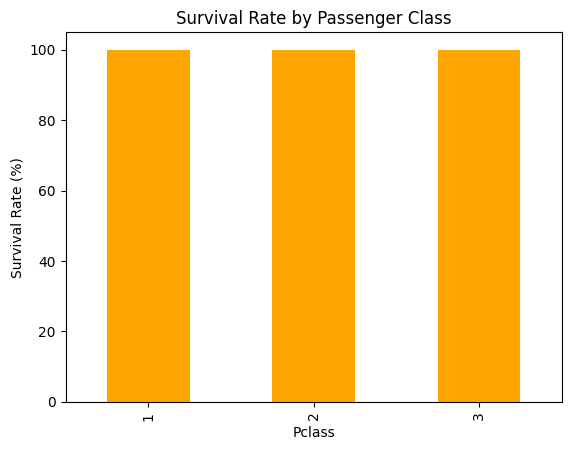

In [1998]:
survival_by_class = df.groupby('Pclass')['Survived'].mean() * 100
survival_by_class.plot(kind='bar', color='orange')
plt.ylabel('Survival Rate (%)')
plt.title('Survival Rate by Passenger Class')
plt.show()
